# 🚢 Modul 1 — Praktikum Statistika & Probabilitas

### Studi Kasus: Titanic Survival Dataset (Kaggle)

**Mata Kuliah:** Statistika & Probabilitas (TIF1501)  
**Program Studi:** Teknik Informatika (55201) · FTI · Uniska MAB Banjarmasin  
**Semester:** 5 · 3 SKS

---

## 🎯 Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, Anda akan mampu:

1. **Menjelaskan** peran statistika & probabilitas dalam era AI Generatif, Machine Learning, dan Data Science.
2. **Menyiapkan** environment kerja: Google Colab + Kaggle + GitHub.
3. **Mengklasifikasi** jenis data (Nominal, Ordinal, Interval, Rasio) dalam konteks feature engineering ML.
4. **Membedakan** populasi vs sampel di era Big Data dan Machine Learning modern.

---

## 📋 Alur Notebook

| Bagian | Isi | Waktu |
|--------|-----|-------|
| **A** | Setup & Verifikasi Environment | 10 menit |
| **B** | Load Dataset Titanic dari Kaggle | 10 menit |
| **C** | Eksplorasi Awal (Exploratory Data Analysis) | 20 menit |
| **D** | Klasifikasi Jenis Data — LATIHAN | 15 menit |
| **E** | Populasi vs Sampel — DEMO & LATIHAN | 15 menit |
| **F** | Mini Feature Engineering | 15 menit |
| **G** | Refleksi & Submit ke GitHub | 5 menit |

**Total: ± 90 menit**

---

## 💡 Kenapa Titanic?

Dataset Titanic dari Kaggle adalah dataset klasik untuk pembelajaran Data Science. Dataset ini berisi informasi 891 penumpang RMS Titanic yang tenggelam pada 15 April 1912. Yang membuatnya sempurna untuk Modul 1:

- ✅ Ukuran kecil (mudah dipahami), hanya 891 baris × 12 kolom.
- ✅ Mengandung **keempat jenis data**: Nominal, Ordinal, Interval, Rasio.
- ✅ Menggambarkan populasi vs sampel dengan jelas (2.224 penumpang asli vs 891 di dataset training).
- ✅ Tersedia gratis dari URL publik — tidak perlu login Kaggle untuk load.
- ✅ Baseline untuk kompetisi Kaggle "Titanic - Machine Learning from Disaster".


---

# 🔧 A. Setup & Verifikasi Environment

**Tujuan:** memastikan Google Colab siap dan library dasar terinstal.

## A.1 Cek Versi Python


In [1]:
# Cek versi Python — pastikan Python 3.8 atau lebih baru
import sys
print(f"Python version: {sys.version}")
print(f"Version info: {sys.version_info}")


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Version info: sys.version_info(major=3, minor=12, micro=13, releaselevel='final', serial=0)


## A.2 Import Library Dasar Data Science

Kita akan pakai stack standar:
- **pandas** — manipulasi data tabular (mirip Excel/SQL)
- **numpy** — komputasi numerik cepat
- **matplotlib & seaborn** — visualisasi


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cek versi library
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"seaborn    : {sns.__version__}")

print("\n✅ Semua library dasar berhasil di-import!")


pandas     : 2.3.3
numpy      : 2.0.2
seaborn    : 0.13.2

✅ Semua library dasar berhasil di-import!


> ✏️ **Latihan A**: Jalankan cell di atas. Screenshot output dan simpan sebagai bukti setup berhasil.


---

# 📥 B. Load Dataset Titanic dari Kaggle

Dataset Titanic tersedia gratis dari beberapa sumber. Kita gunakan URL publik dari GitHub agar tidak perlu setup Kaggle API. Untuk penggunaan tingkat lanjut nanti (M9+), kita akan setup Kaggle API.

## B.1 Load dari URL Publik


In [3]:
# URL dataset Titanic dari repository publik
#url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
JALUR = '/kaggle/input/datasets/brendan45774/test-file/tested.csv'
# Baca CSV langsung dari URL
df = pd.read_csv(JALUR)

# Tampilkan 5 baris pertama
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## B.2 Alternatif: Download dari Kaggle (Optional)

Kalau ingin latihan menggunakan Kaggle API, ikuti langkah berikut:

```python
# 1. Install kaggle
!pip install kaggle -q

# 2. Upload kaggle.json (dari Account Kaggle > API > Create New Token)
from google.colab import files
files.upload()

# 3. Set permission dan download
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c titanic
!unzip -o titanic.zip
```

**Untuk Modul 1, cukup pakai URL publik saja.**


---

# 🔍 C. Eksplorasi Awal (EDA — Exploratory Data Analysis)

**Tujuan:** memahami struktur, ukuran, dan kualitas dataset SEBELUM analisis mendalam.

## C.1 Ukuran Dataset


In [4]:
# Cek dimensi: berapa baris & kolom?
n_rows, n_cols = df.shape
print(f"Jumlah baris (observasi): {n_rows}")
print(f"Jumlah kolom (fitur)    : {n_cols}")
print(f"\nUkuran total sel: {n_rows * n_cols:,}")


Jumlah baris (observasi): 418
Jumlah kolom (fitur)    : 12

Ukuran total sel: 5,016


## C.2 Nama Kolom & Deskripsi

Deskripsi resmi kolom Titanic:

| Kolom | Deskripsi |
|-------|-----------|
| **PassengerId** | ID unik penumpang |
| **Survived** | 0 = meninggal, 1 = selamat (label target) |
| **Pclass** | Kelas tiket: 1 = 1st class, 2 = 2nd, 3 = 3rd |
| **Name** | Nama lengkap |
| **Sex** | Jenis kelamin: male / female |
| **Age** | Umur (tahun); ada nilai missing |
| **SibSp** | Jumlah saudara/pasangan di kapal |
| **Parch** | Jumlah orang tua/anak di kapal |
| **Ticket** | Nomor tiket |
| **Fare** | Harga tiket (£ Pound) |
| **Cabin** | Nomor kabin (banyak missing) |
| **Embarked** | Pelabuhan naik: C=Cherbourg, Q=Queenstown, S=Southampton |


In [5]:
# Lihat semua nama kolom
print("Kolom-kolom di dataset Titanic:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


Kolom-kolom di dataset Titanic:
   1. PassengerId
   2. Survived
   3. Pclass
   4. Name
   5. Sex
   6. Age
   7. SibSp
   8. Parch
   9. Ticket
  10. Fare
  11. Cabin
  12. Embarked


## C.3 Tipe Data Setiap Kolom


In [6]:
# df.info() memberi ringkasan lengkap
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


> 🔍 **Perhatikan:**
> - Kolom `object` = string (kategorik).
> - Kolom `int64` / `float64` = numerik.
> - Kolom `Age` dan `Cabin` punya nilai missing (non-null count < 891).


## C.4 Statistik Deskriptif Numerik

Kita gunakan `df.describe()` untuk melihat ringkasan kolom numerik:


In [7]:
# Statistik deskriptif untuk kolom numerik
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## C.5 Statistik untuk Kolom Kategorik


In [8]:
# Statistik untuk kolom object (string/kategorik)
df.describe(include=['object'])


,Name,Sex,Ticket,Cabin,Embarked
count,418,418,418,91,418
unique,418,2,363,76,3
top,"Peter, Master. Michael J",male,PC 17608,B57 B59 B63 B66,S
freq,1,266,5,3,270


> 💡 **Insight:**
> - Ada **577 laki-laki** dari 891 penumpang (~65%).
> - Ada **644 penumpang** naik dari Southampton (S) — pelabuhan terbesar.
> - Semua nama unik (`unique = 891`), berarti tidak ada duplikasi ID.


## C.6 Cek Missing Value


In [9]:
# Hitung missing value per kolom
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print("Ringkasan Missing Value:")
missing_summary[missing_summary['Missing Count'] > 0]


Ringkasan Missing Value:


,Missing Count,Percentage (%)
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


> ⚠️ **Temuan:**
> - `Cabin` — 687 missing (77%): pertimbangkan drop atau buat fitur `has_cabin`.
> - `Age` — 177 missing (20%): perlu imputasi (mis. median).
> - `Embarked` — 2 missing: bisa diisi dengan modus.


## C.7 Visualisasi Cepat: Distribusi Survival


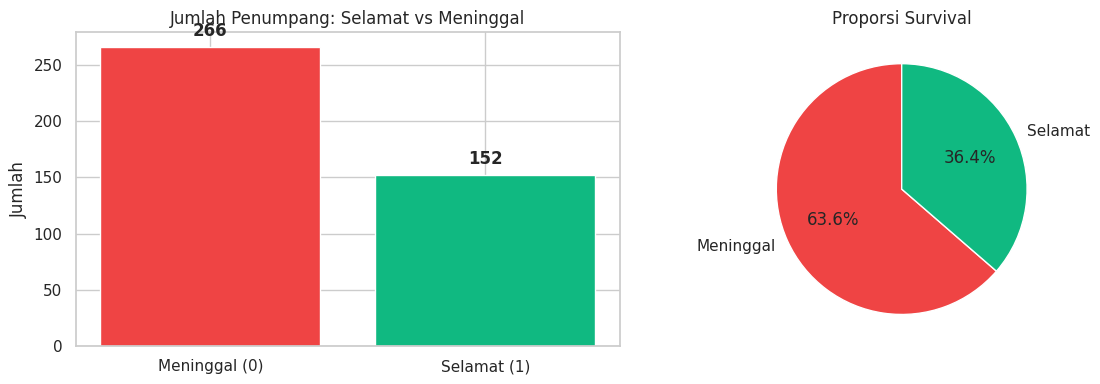


Tingkat kelangsungan hidup: 36.36%


In [10]:
# Bar chart: berapa yang selamat vs meninggal?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: count
survived_count = df['Survived'].value_counts()
axes[0].bar(['Meninggal (0)', 'Selamat (1)'], survived_count.values,
            color=['#EF4444', '#10B981'])
axes[0].set_title('Jumlah Penumpang: Selamat vs Meninggal')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(survived_count.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Right: proporsi
axes[1].pie(survived_count.values, labels=['Meninggal', 'Selamat'],
            colors=['#EF4444', '#10B981'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Survival')

plt.tight_layout()
plt.show()

print(f"\nTingkat kelangsungan hidup: {df['Survived'].mean() * 100:.2f}%")


> 📊 Sekitar **38%** penumpang selamat. Ini menjadi baseline untuk model klasifikasi nanti di modul selanjutnya.


---

# 🏷️ D. Klasifikasi Jenis Data — LATIHAN UTAMA

**Ini adalah latihan inti Modul 1.** Anda akan mengklasifikasi setiap kolom Titanic ke dalam salah satu dari empat jenis data:

| Jenis | Ciri Utama | Contoh |
|-------|-----------|--------|
| **Nominal** | Kategori tanpa urutan | Warna, jenis kelamin, kota |
| **Ordinal** | Kategori dengan urutan, jarak tidak sama | Rating, pendidikan, kelas |
| **Interval** | Numerik, jarak sama, TIDAK ada 0 absolut | Suhu Celsius, tahun kalender |
| **Rasio** | Numerik, jarak sama, ADA 0 absolut | Berat, tinggi, harga, umur |

## D.1 Analisis Kolom Sex


In [11]:
# Cek nilai unik kolom Sex
print("Nilai unik:", df['Sex'].unique())
print("\nFrekuensi:")
print(df['Sex'].value_counts())


Nilai unik: ['male' 'female']

Frekuensi:
Sex
male      266
female    152
Name: count, dtype: int64


**Pertanyaan D.1:** Jenis apa kolom `Sex`?

**Jawaban:** **NOMINAL** ✅
- Ada 2 kategori: male, female
- Tidak ada urutan (male tidak "lebih besar" dari female)
- Operasi hanya `=` dan `≠`
- Untuk ML: encode dengan **one-hot encoding** atau binary (0/1)


## D.2 Analisis Kolom Pclass


In [12]:
# Cek Pclass
print("Nilai unik Pclass:", sorted(df['Pclass'].unique()))
print("\nFrekuensi:")
print(df['Pclass'].value_counts().sort_index())


Nilai unik Pclass: [np.int64(1), np.int64(2), np.int64(3)]

Frekuensi:
Pclass
1    107
2     93
3    218
Name: count, dtype: int64


**Pertanyaan D.2:** Jenis apa kolom `Pclass`?

**Jawaban:** **ORDINAL** ✅
- Ada 3 kategori: 1, 2, 3 (kelas 1, 2, 3)
- ADA urutan: kelas 1 > kelas 2 > kelas 3 (dari sisi harga/kemewahan)
- TAPI jarak tidak sama: selisih harga kelas 1-2 ≠ kelas 2-3
- Operasi: `<`, `>`, `=`
- Untuk ML: gunakan **label encoding urut** atau biarkan sebagai angka


## D.3 Analisis Kolom Embarked


In [13]:
print("Nilai unik Embarked:", df['Embarked'].unique())
print("\nFrekuensi:")
print(df['Embarked'].value_counts())


Nilai unik Embarked: ['Q' 'S' 'C']

Frekuensi:
Embarked
S    270
C    102
Q     46
Name: count, dtype: int64


**Pertanyaan D.3:** Jenis apa kolom `Embarked`?

**Jawaban:** **NOMINAL** ✅
- 3 kategori kota: Cherbourg, Queenstown, Southampton
- Tidak ada urutan yang bermakna (mengurutkan Cherbourg > Queenstown tidak masuk akal)
- Untuk ML: **one-hot encoding** — jangan encode 1, 2, 3!


## D.4 Analisis Kolom Age


Min umur    : 0.17
Max umur    : 76.0
Median      : 27.0
Mean        : 30.27


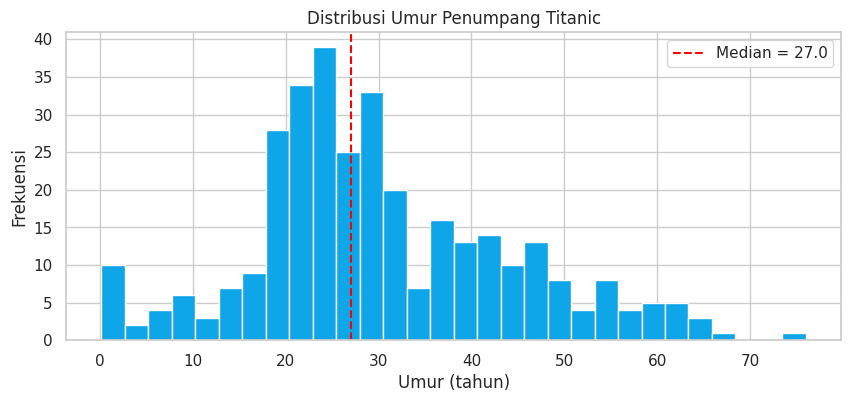

In [14]:
# Statistik umur
print(f"Min umur    : {df['Age'].min()}")
print(f"Max umur    : {df['Age'].max()}")
print(f"Median      : {df['Age'].median()}")
print(f"Mean        : {df['Age'].mean():.2f}")

# Histogram
plt.figure(figsize=(10, 4))
plt.hist(df['Age'].dropna(), bins=30, color='#0EA5E9', edgecolor='white')
plt.title('Distribusi Umur Penumpang Titanic')
plt.xlabel('Umur (tahun)')
plt.ylabel('Frekuensi')
plt.axvline(df['Age'].median(), color='red', linestyle='--',
            label=f'Median = {df["Age"].median()}')
plt.legend()
plt.show()


**Pertanyaan D.4:** Jenis apa kolom `Age`?

**Jawaban:** **RASIO** ✅
- Numerik kontinu (0.42 tahun sampai 80 tahun)
- Jarak sama: perbedaan 10-20 tahun = perbedaan 30-40 tahun
- **ADA 0 absolut**: umur 0 = tidak ada umur / baru lahir
- Rasio bermakna: umur 40 = 2× umur 20
- Untuk ML: gunakan `StandardScaler` atau `MinMaxScaler`


## D.5 Analisis Kolom Fare


Min fare : £0.00
Max fare : £512.33
Median   : £14.45
Mean     : £35.63


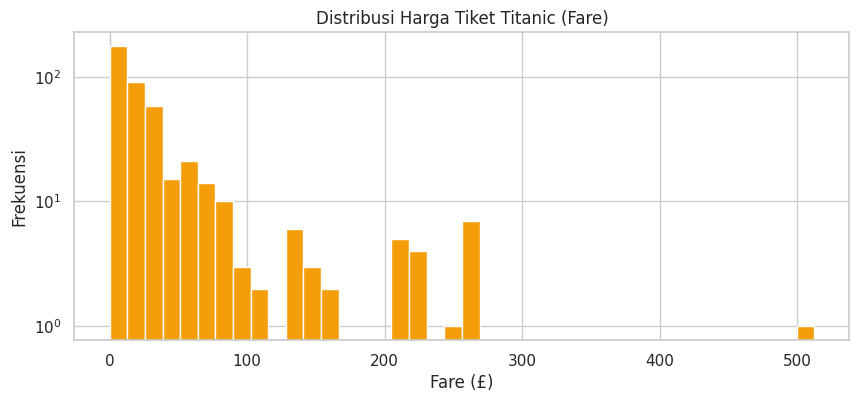

In [15]:
# Statistik Fare (harga tiket)
print(f"Min fare : £{df['Fare'].min():.2f}")
print(f"Max fare : £{df['Fare'].max():.2f}")
print(f"Median   : £{df['Fare'].median():.2f}")
print(f"Mean     : £{df['Fare'].mean():.2f}")

# Histogram (log scale karena skewed)
plt.figure(figsize=(10, 4))
plt.hist(df['Fare'], bins=40, color='#F59E0B', edgecolor='white')
plt.title('Distribusi Harga Tiket Titanic (Fare)')
plt.xlabel('Fare (£)')
plt.ylabel('Frekuensi')
plt.yscale('log')
plt.show()


**Pertanyaan D.5:** Jenis apa kolom `Fare`?

**Jawaban:** **RASIO** ✅
- Numerik kontinu
- ADA 0 absolut: Fare = 0 berarti gratis (memang ada penumpang gratisan, kemungkinan crew!)
- Distribusi sangat skewed → untuk ML, pertimbangkan **transformasi log**: `np.log1p(df['Fare'])`


## D.6 LATIHAN Anda — Isi Sendiri!

Klasifikasi kolom berikut dan jelaskan alasannya. Isi jawaban Anda pada cell markdown di bawah.


In [16]:
# Cell bantuan — cek nilai unik dulu
kolom_untuk_dianalisis = ['SibSp', 'Parch', 'Ticket', 'Cabin', 'Survived']

for col in kolom_untuk_dianalisis:
    print(f"\n=== {col} ===")
    print(f"Tipe pandas: {df[col].dtype}")
    print(f"Jumlah nilai unik: {df[col].nunique()}")
    if df[col].nunique() < 15:
        print(f"Nilai: {df[col].unique()}")
    else:
        print(f"Sample: {df[col].dropna().sample(5).tolist()}")



=== SibSp ===
Tipe pandas: int64
Jumlah nilai unik: 7
Nilai: [0 1 2 3 4 5 8]

=== Parch ===
Tipe pandas: int64
Jumlah nilai unik: 8
Nilai: [0 1 3 2 4 6 5 9]

=== Ticket ===
Tipe pandas: object
Jumlah nilai unik: 363
Sample: ['33638', '330971', '2662', '386525', '11770']

=== Cabin ===
Tipe pandas: object
Jumlah nilai unik: 76
Sample: ['E39 E41', 'B52 B54 B56', 'D34', 'B41', 'B36']

=== Survived ===
Tipe pandas: int64
Jumlah nilai unik: 2
Nilai: [0 1]


### ✏️ Jawaban Anda:

| Kolom | Jenis Data | Alasan Singkat |
|-------|-----------|----------------|
| SibSp | Rasio | Angka 0 berarti benar-benar tidak membawa saudara/pasangan, dan selisih antar nilai bermakna konsisten |
| Parch | Rasio | Sama seperti SibSp, angka 0 berarti tidak membawa orang tua/anak, ada nol absolut dan selisihnya bermakna |
| Ticket | Nominal | Hanya kode/label pembeda tiket, tidak ada urutan atau makna kuantitatif di angkanya |
| Cabin | Nominal | Kode lokasi kabin, sekadar label kategori bukan angka yang bisa dibandingkan besar kecilnya |
| Survived | Nominal | Meski berupa 0 dan 1, itu cuma kode kategori meninggal/selamat, bukan angka yang bisa dijumlah atau diurutkan |

> 💡 **Hint:** Perhatikan apakah kolom punya urutan, ada 0 absolut, atau hanya kategori.


## D.7 Ringkasan Klasifikasi (Kunci Jawaban Lengkap)

| Kolom | Jenis | Penjelasan | Encoding ML |
|-------|-------|-----------|-------------|
| PassengerId | **Nominal** | ID unik, hanya identifier | Buang (tidak berguna untuk model) |
| Survived | **Nominal** | Label biner 0/1 | Sudah OK |
| Pclass | **Ordinal** | Kelas 1 > 2 > 3 | Label encoding |
| Name | **Nominal** | Teks bebas | Ekstrak title (Mr/Mrs) → nominal |
| Sex | **Nominal** | male/female | One-hot atau binary |
| Age | **Rasio** | 0 = tidak ada umur | StandardScaler |
| SibSp | **Rasio** | Jumlah, 0 = sendirian | StandardScaler |
| Parch | **Rasio** | Jumlah, 0 = sendirian | StandardScaler |
| Ticket | **Nominal** | Kode tiket | One-hot atau buang |
| Fare | **Rasio** | Harga, 0 = gratis | Log transform + Scaler |
| Cabin | **Nominal** | Kode kabin | Buat fitur has_cabin |
| Embarked | **Nominal** | 3 pelabuhan tanpa urutan | One-hot encoding |


---

# 👥 E. Populasi vs Sampel

## E.1 Diskusi Konsep

**Pertanyaan Kunci:**
> Dataset kita punya **891 baris**. Apakah ini populasi atau sampel?

**Jawaban:**
- **Populasi sesungguhnya** = seluruh penumpang RMS Titanic pada 15 April 1912 = **2.224 orang** (menurut catatan sejarah).
- **Dataset yang kita punya** = **891 orang** (data training Kaggle) = **SAMPEL** dari populasi asli.
- Data test Kaggle memiliki 418 baris tambahan, sehingga total data Kaggle = 1.309, masih di bawah 2.224.

### Kenapa Data Tidak Lengkap?
- Sebagian catatan hilang dalam kekacauan malam kejadian.
- Kaggle sengaja membagi data menjadi train (891) + test (418) untuk kompetisi.
- Ini menggambarkan realita: **kita jarang punya "seluruh data"** — hampir selalu bekerja dengan sampel.

## E.2 Simulasi Sampling dari "Populasi"

Anggap saja 891 baris kita adalah "populasi mini" untuk latihan. Kita akan ambil sampel dari sini.


In [17]:
# Populasi = seluruh data yang kita miliki
populasi = df.copy()
print(f"Ukuran populasi: N = {len(populasi):,}")

# Sampel 1: Random sampling n=100
sampel_random = populasi.sample(n=100, random_state=42)
print(f"\nSampel Random: n = {len(sampel_random)}")
print(f"  Mean umur populasi: {populasi['Age'].mean():.2f} tahun")
print(f"  Mean umur sampel  : {sampel_random['Age'].mean():.2f} tahun")
print(f"  Selisih           : {abs(populasi['Age'].mean() - sampel_random['Age'].mean()):.2f} tahun")


Ukuran populasi: N = 418

Sampel Random: n = 100
  Mean umur populasi: 30.27 tahun
  Mean umur sampel  : 29.74 tahun
  Selisih           : 0.54 tahun


> 💡 **Insight:** Meskipun hanya ambil 100 dari 891 baris (~11%), mean umur sampel biasanya sudah dekat dengan populasi. Inilah kekuatan sampling yang baik!


## E.3 Perbandingan: Random vs Stratified Sampling

**Masalah dengan Random Sampling:** kadang sampel tidak proporsional terhadap kategori penting.

**Solusi:** **Stratified Sampling** — bagi populasi berdasarkan kolom penting (mis. `Pclass`), sampel proporsional dari tiap kelompok.


In [18]:
from sklearn.model_selection import train_test_split

# Random sampling (dasar)
_, sampel_random = train_test_split(populasi, test_size=100, random_state=42)

# Stratified sampling berdasarkan Pclass
_, sampel_strat = train_test_split(populasi, test_size=100,
                                    stratify=populasi['Pclass'],
                                    random_state=42)

print("Proporsi Pclass di POPULASI:")
print((populasi['Pclass'].value_counts(normalize=True) * 100).round(1))

print("\nProporsi Pclass di sampel RANDOM (n=100):")
print((sampel_random['Pclass'].value_counts(normalize=True) * 100).round(1))

print("\nProporsi Pclass di sampel STRATIFIED (n=100):")
print((sampel_strat['Pclass'].value_counts(normalize=True) * 100).round(1))


Proporsi Pclass di POPULASI:
Pclass
3    52.2
1    25.6
2    22.2
Name: proportion, dtype: float64

Proporsi Pclass di sampel RANDOM (n=100):
Pclass
3    49.0
2    26.0
1    25.0
Name: proportion, dtype: float64

Proporsi Pclass di sampel STRATIFIED (n=100):
Pclass
3    52.0
1    26.0
2    22.0
Name: proportion, dtype: float64


> 📌 **Perhatikan:** Sampel stratified proporsinya lebih mirip populasi. Ini penting untuk data yang imbalanced (mis. deteksi fraud, di mana kelas "fraud" hanya 1%).


## E.4 Visualisasi Bias Sampling


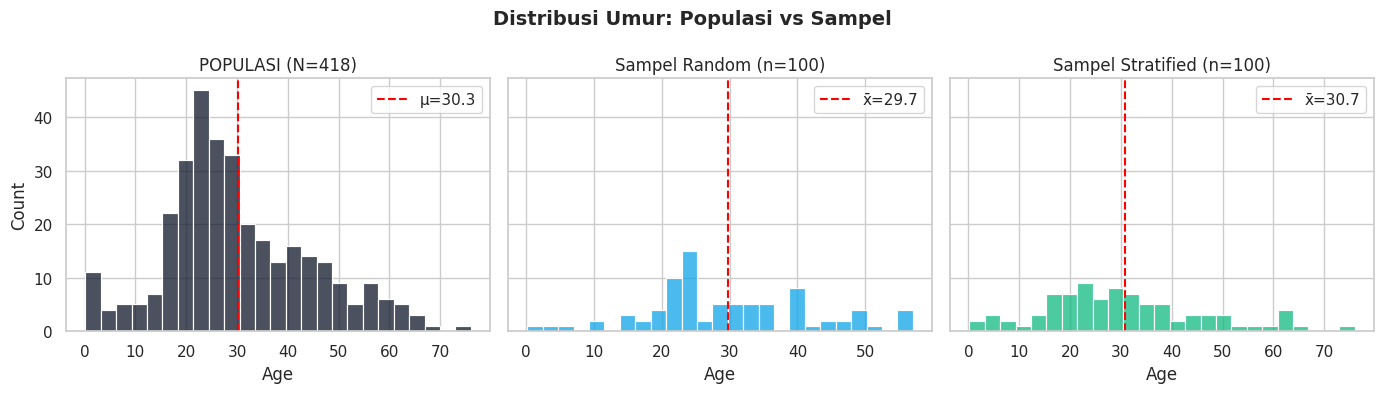

In [19]:
# Bandingkan distribusi umur: populasi vs sampel
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

sns.histplot(populasi['Age'].dropna(), bins=25, ax=axes[0], color='#0F172A')
axes[0].set_title(f'POPULASI (N={len(populasi)})')
axes[0].axvline(populasi['Age'].mean(), color='red', ls='--',
                label=f'μ={populasi["Age"].mean():.1f}')
axes[0].legend()

sns.histplot(sampel_random['Age'].dropna(), bins=25, ax=axes[1], color='#0EA5E9')
axes[1].set_title(f'Sampel Random (n={len(sampel_random)})')
axes[1].axvline(sampel_random['Age'].mean(), color='red', ls='--',
                label=f'x̄={sampel_random["Age"].mean():.1f}')
axes[1].legend()

sns.histplot(sampel_strat['Age'].dropna(), bins=25, ax=axes[2], color='#10B981')
axes[2].set_title(f'Sampel Stratified (n={len(sampel_strat)})')
axes[2].axvline(sampel_strat['Age'].mean(), color='red', ls='--',
                label=f'x̄={sampel_strat["Age"].mean():.1f}')
axes[2].legend()

plt.suptitle('Distribusi Umur: Populasi vs Sampel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

# ⚙️ F. Mini Feature Engineering

Sekarang praktikkan encoding yang tepat untuk setiap jenis data.

## F.1 One-Hot Encoding untuk Nominal (Sex, Embarked)


In [20]:
# Metode 1: pd.get_dummies (paling ringkas)
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'],
                             prefix=['Sex', 'Embarked'], drop_first=False)

# Tampilkan kolom baru
new_cols = [c for c in df_encoded.columns if c.startswith(('Sex_', 'Embarked_'))]
print("Kolom baru hasil one-hot encoding:")
print(new_cols)

print("\nSample data setelah encoding:")
df_encoded[new_cols].head()


Kolom baru hasil one-hot encoding:
['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

Sample data setelah encoding:


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,False,True,False,True,False
1,True,False,False,False,True
2,False,True,False,True,False
3,False,True,False,False,True
4,True,False,False,False,True


## F.2 Label Encoding untuk Ordinal (Pclass)

Pclass sudah numerik (1, 2, 3), tapi kita bisa balik agar 1st class = angka terbesar:


In [21]:
# Karena 1st class = paling mewah, kita balik agar angka lebih besar = lebih mewah
pclass_mapping = {1: 3, 2: 2, 3: 1}  # 1st→3, 2nd→2, 3rd→1
df['PclassLevel'] = df['Pclass'].map(pclass_mapping)

# Verifikasi
print("Pclass asli vs PclassLevel:")
print(df[['Pclass', 'PclassLevel']].drop_duplicates().sort_values('Pclass'))


Pclass asli vs PclassLevel:
    Pclass  PclassLevel
11       1            3
2        2            2
0        3            1


## F.3 Scaling untuk Rasio (Age, Fare)


In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Isi missing Age dengan median dulu
df['Age_filled'] = df['Age'].fillna(df['Age'].median())

# Metode 1: StandardScaler (Z-score) → cocok untuk Age
scaler_z = StandardScaler()
df['Age_zscore'] = scaler_z.fit_transform(df[['Age_filled']])

# Metode 2: MinMaxScaler (0-1) → alternatif untuk Age
scaler_mm = MinMaxScaler()
df['Age_minmax'] = scaler_mm.fit_transform(df[['Age_filled']])

# Untuk Fare yang skewed, gunakan log transform DULU sebelum scaling
df['Fare_log'] = np.log1p(df['Fare'])

# Verifikasi hasil
print("Contoh 5 baris:")
df[['Age', 'Age_zscore', 'Age_minmax', 'Fare', 'Fare_log']].head()


Contoh 5 baris:


,Age,Age_zscore,Age_minmax,Fare,Fare_log
0,34.5,0.386231,0.452723,7.8292,2.178064
1,47.0,1.371370,0.617566,7.0000,2.079442
2,62.0,2.553537,0.815377,9.6875,2.369075
3,27.0,-0.204852,0.353818,8.6625,2.268252
4,22.0,-0.598908,0.287881,12.2875,2.586824


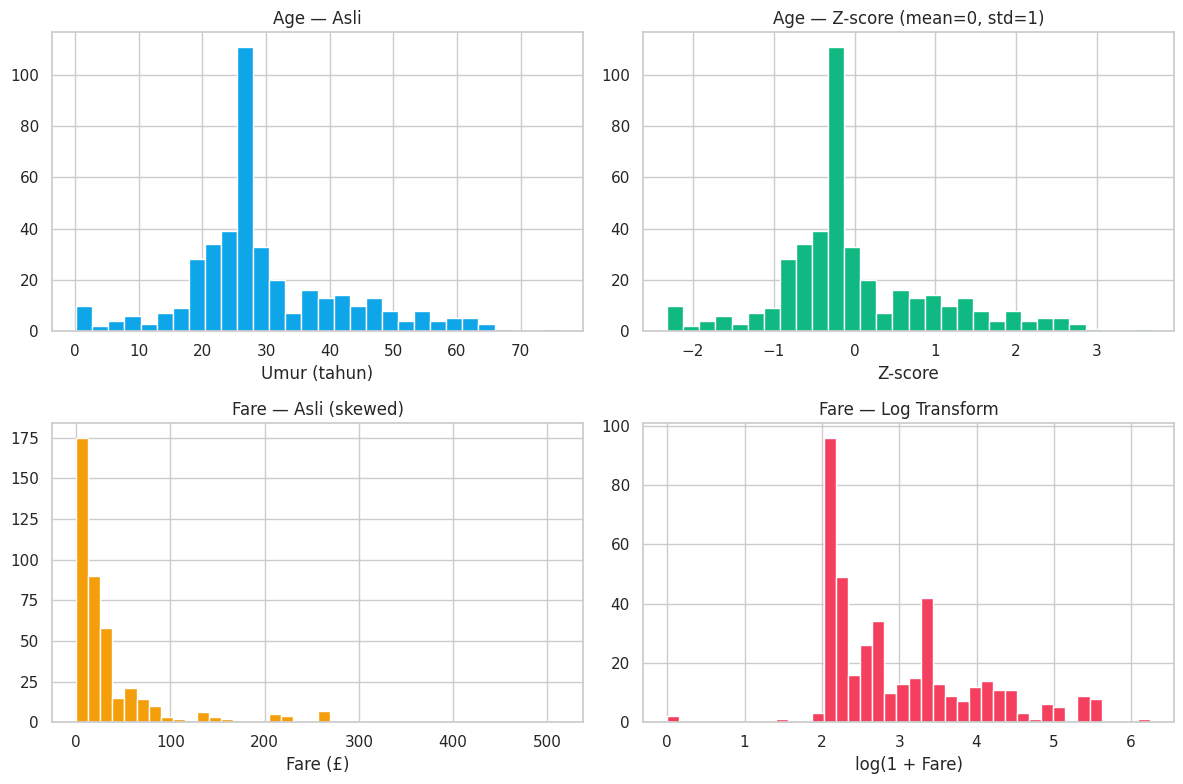

In [23]:
# Visualisasi: sebelum & sesudah scaling
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(df['Age_filled'], bins=30, color='#0EA5E9')
axes[0,0].set_title('Age — Asli')
axes[0,0].set_xlabel('Umur (tahun)')

axes[0,1].hist(df['Age_zscore'], bins=30, color='#10B981')
axes[0,1].set_title('Age — Z-score (mean=0, std=1)')
axes[0,1].set_xlabel('Z-score')

axes[1,0].hist(df['Fare'], bins=40, color='#F59E0B')
axes[1,0].set_title('Fare — Asli (skewed)')
axes[1,0].set_xlabel('Fare (£)')

axes[1,1].hist(df['Fare_log'], bins=40, color='#F43F5E')
axes[1,1].set_title('Fare — Log Transform')
axes[1,1].set_xlabel('log(1 + Fare)')

plt.tight_layout()
plt.show()


> 📌 **Insight:** Log transform mengubah distribusi Fare dari sangat skewed menjadi mendekati normal. Ini penting agar model ML tidak terpengaruh outlier ekstrem.


---

# 📝 G. Refleksi & Submit

## G.1 Pertanyaan Refleksi

Jawab 5 pertanyaan berikut di cell markdown di bawah:

1. **Peran Statistika:** Berikan 1 contoh nyata di mana statistika probabilistik menentukan output ChatGPT/Claude/Gemini.

2. **Jenis Data:** Jelaskan mengapa mengubah kolom `Embarked` (C, Q, S) menjadi angka 1, 2, 3 akan menyesatkan model ML.

3. **Populasi vs Sampel:** Jika Anda ingin memprediksi survival pada penumpang Titanic yang tidak ada di dataset, apakah 891 baris cukup? Kenapa?

4. **Feature Engineering:** Kenapa `Fare` perlu di-log transform sebelum training model?

5. **Refleksi Pribadi:** Apa hal paling menarik yang Anda pelajari di Modul 1 ini?

### ✏️ Jawaban Anda:

**1.** Salah satu contoh nyata peran statistika probabilistik ada pada cara ChatGPT, Claude, atau Gemini menghasilkan jawaban. Saat model menyusun kalimat, ia tidak memilih kata secara pasti atau berdasarkan aturan tetap, melainkan menghitung peluang kemunculan setiap kata yang mungkin muncul berikutnya, lalu memilih salah satu berdasarkan distribusi peluang tersebut. Itulah sebabnya kalau kita menanyakan hal yang sama dua kali, jawabannya bisa sedikit berbeda meskipun maknanya tetap konsisten. Jadi output AI generatif pada dasarnya adalah hasil dari proses sampling probabilistik, bukan pemilihan kata yang deterministik.

**2.** Kolom Embarked berisi C, Q, dan S yang menunjukkan pelabuhan keberangkatan penumpang. Jika nilai ini diubah menjadi angka 1, 2, dan 3, model akan menganggap ada urutan atau tingkatan di antara ketiganya, padahal sebenarnya tidak ada hubungan lebih besar atau lebih kecil antar pelabuhan tersebut. Embarked termasuk data nominal, jadi mengubahnya jadi angka berurutan justru menciptakan makna palsu yang bisa membuat model salah belajar pola. Cara yang lebih tepat adalah menggunakan one hot encoding supaya setiap kategori diperlakukan setara tanpa asumsi urutan.

**3.** Dataset yang saya gunakan di notebook ini sebenarnya berjumlah 418 baris, bukan 891 seperti disebutkan pada teks soal, karena file yang dimuat adalah tested.csv. Terlepas dari itu, jumlah data yang lebih sedikit tidak otomatis berarti tidak cukup untuk memprediksi penumpang lain. Yang lebih menentukan adalah apakah sampel tersebut cukup mewakili populasi aslinya yang berjumlah sekitar 2224 orang, baik dari segi proporsi kelas, jenis kelamin, maupun usia. Kalau distribusinya sudah proporsional, 418 data pun bisa cukup representatif, tapi kalau distribusinya timpang maka model yang dilatih dari data ini bisa saja gagal digeneralisasi ke penumpang lain di luar dataset.

**4.** Sebelum dilakukan log transform, distribusi Fare sangat menceng ke kanan dengan nilai skewness sekitar 3,69, karena sebagian kecil penumpang kelas satu membayar tarif yang jauh lebih tinggi dibanding mayoritas penumpang lain. Setelah dilakukan log transform, skewness turun menjadi sekitar 0,86 yang berarti distribusinya menjadi jauh lebih mendekati normal. Ini penting dilakukan karena banyak algoritma machine learning bekerja lebih baik saat data numerik mendekati distribusi normal, dan tanpa transformasi ini nilai ekstrem pada Fare bisa mendominasi proses pembelajaran model sehingga hasilnya menjadi bias.

**5.** Hal yang paling menarik buat saya adalah saat dosen menjelaskan bagaimana AI bekerja ketika seseorang mengetik kalimat seperti "aku suka makan...". Ternyata AI tidak langsung menebak satu jawaban pasti, melainkan menghitung peluang dari berbagai kemungkinan kata berikutnya, misalnya 58 persen kemungkinan lanjutannya adalah nasi, 13 persen sate, dan seterusnya, lalu memilih salah satu berdasarkan peluang tersebut. Dari situ saya baru sadar bahwa hal yang selama ini terlihat seperti AI "berpikir" sebenarnya adalah perhitungan probabilistik murni.
Selain itu, saat mencoba menggunakan Kaggle di praktikum ini, saya jadi kepikiran bahwa cara kerja yang sama sebenarnya bisa diterapkan untuk kasus yang lebih dekat dengan kondisi di sekitar saya, misalnya menghitung dan membaca pola kejadian kebakaran hutan dan lahan (karhutla) yang berulang tiap tahun di Pulau Kalimantan. Kalau datanya tersedia, kita bisa mengolahnya dengan pendekatan statistik serupa seperti yang dipakai di dataset Titanic ini, untuk melihat pola musim, wilayah, atau faktor lain yang berkontribusi terhadap kejadian tersebut secara berulang.


## G.2 Checklist Submit

Sebelum submit, pastikan:

- [x] Semua cell code berhasil dijalankan tanpa error
- [x] Latihan D.6 sudah diisi (klasifikasi 5 kolom)
- [x] 5 pertanyaan refleksi sudah dijawab
- [x] Notebook di-rename: `M1-Praktikum-Titanic-NamaAnda.ipynb`
- [x] Notebook di-download dari Colab (File → Download → .ipynb)
- [x] Notebook di-upload ke GitHub repository Anda
- [x] Link GitHub dikumpulkan via LMS Uniska

## G.3 Cara Push ke GitHub

**Melalui Web (paling mudah):**
1. Buka repository GitHub Anda: `statistika-probabilitas-uniska`.
2. Klik folder `notebooks/`, lalu tombol **Add file → Upload files**.
3. Drag & drop file `M1-Praktikum-Titanic-NamaAnda.ipynb`.
4. Tulis commit message: `"Add Modul 1 praktikum: Titanic EDA"`.
5. Klik **Commit changes**.

**Melalui Git command (bonus, untuk yang mau belajar):**
```bash
git clone https://github.com/username/statistika-probabilitas-uniska.git
cd statistika-probabilitas-uniska/notebooks
cp /path/to/M1-Praktikum-Titanic-NamaAnda.ipynb .
git add .
git commit -m "Add Modul 1 praktikum: Titanic EDA"
git push
```


---

## 🎓 Selamat!

Anda telah menyelesaikan Modul 1 dan berhasil:

✅ Memahami peran statistika di era AI Generatif  
✅ Setup Colab + Kaggle + GitHub  
✅ Klasifikasi Nominal, Ordinal, Interval, Rasio pada dataset nyata  
✅ Membedakan populasi vs sampel dan melakukan sampling  
✅ Mini feature engineering (one-hot, label, scaling, log transform)

## 📚 Bacaan Lanjutan

- **VanderPlas, J.** (2023). *Python Data Science Handbook*, Chapter 3: Data Manipulation with pandas.
- **Bruce, P.** (2020). *Practical Statistics for Data Scientists*, Chapter 1: Exploratory Data Analysis.
- **Kaggle Learn** — [Intro to Machine Learning](https://www.kaggle.com/learn/intro-to-machine-learning).

## 🔮 Persiapan Modul 2

Modul 2 akan membahas **fondasi probabilitas** untuk Machine Learning:
- Ruang sampel & event
- Probabilitas bersyarat
- Kombinatorik untuk grid search
- Train/test/validation split sebagai probabilistic sampling

**Tugas Mandiri sebelum M2:**
1. Selesaikan Kaggle Learn "Intro to Programming" (2 jam).
2. Baca VanderPlas Bab 1 (IPython & Jupyter).
3. Siapkan 1 pertanyaan tentang probabilitas untuk diskusi kelas.

---

*Notebook by: Prodi Teknik Informatika · Uniska MAB Banjarmasin · Edisi 2026*
